In [2]:
from pathlib import Path
import pandas as pd

# Jupyter ya está ejecutándose desde la raíz del proyecto
PROYECTO = Path.cwd()

print(PROYECTO)


C:\Users\HP\Documents\Tesis\R\tesis_solenodon


In [3]:
ruta_datos = PROYECTO / "datos" / "datos_modelo_forrajeo_python.csv"

print(ruta_datos)
print(ruta_datos.exists())

C:\Users\HP\Documents\Tesis\R\tesis_solenodon\datos\datos_modelo_forrajeo_python.csv
True


In [4]:
datos = pd.read_csv(ruta_datos)

print("Dimensiones:", datos.shape)
print("\nDetección de forrajeo:")
print(datos["deteccion_forrajeo"].value_counts().sort_index())

print("\nTipos de variables:")
print(datos.dtypes)

Dimensiones: (4520, 8)

Detección de forrajeo:
deteccion_forrajeo
0    4453
1      67
Name: count, dtype: int64

Tipos de variables:
id_segmento             int64
deteccion_forrajeo      int64
dist_carretera_m        int64
dist_impact_m         float64
elev_mean             float64
pend_mean             float64
chm_mean              float64
forma_relieve             str
dtype: object


In [5]:
datos.isna().sum()

id_segmento           0
deteccion_forrajeo    0
dist_carretera_m      0
dist_impact_m         0
elev_mean             0
pend_mean             0
chm_mean              0
forma_relieve         0
dtype: int64

In [6]:
# Variable respuesta
y = datos["deteccion_forrajeo"].copy()

# Variables predictoras
X = datos[
    [
        "dist_carretera_m",
        "dist_impact_m",
        "elev_mean",
        "pend_mean",
        "chm_mean",
        "forma_relieve"
    ]
].copy()

print("X:", X.shape)
print("y:", y.shape)

print("\nDistribución de la respuesta:")
print(y.value_counts())

X: (4520, 6)
y: (4520,)

Distribución de la respuesta:
deteccion_forrajeo
0    4453
1      67
Name: count, dtype: int64


In [7]:
X = pd.get_dummies(
    X,
    columns=["forma_relieve"],
    drop_first=False,
    dtype=int
)

X.head()

,dist_carretera_m,dist_impact_m,elev_mean,pend_mean,chm_mean,forma_relieve_negativo,forma_relieve_neutral,forma_relieve_positivo
0,674,6.102856,468.022995,6.674387,4.452632,0,0,1
1,674,4.981202,466.421054,7.937687,2.493976,0,1,0
2,673,3.651916,465.050088,7.376310,4.283951,1,0,0
3,676,5.425953,463.672501,9.026440,0.610390,1,0,0
4,672,0.220821,463.766998,7.962821,0.756098,0,1,0


In [8]:
print(X.columns.tolist())
print(X.shape)

['dist_carretera_m', 'dist_impact_m', 'elev_mean', 'pend_mean', 'chm_mean', 'forma_relieve_negativo', 'forma_relieve_neutral', 'forma_relieve_positivo']
(4520, 8)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

# Validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

# Random Forest base
rf_base = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=123,
    n_jobs=-1
)

# Predicciones fuera de muestra para cada fold
prob_rf_base = cross_val_predict(
    rf_base,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Métricas
roc_auc_rf = roc_auc_score(y, prob_rf_base)
pr_auc_rf = average_precision_score(y, prob_rf_base)

print("ROC-AUC validado:", roc_auc_rf)
print("PR-AUC validado:", pr_auc_rf)
print("Prevalencia basal:", y.mean())

ROC-AUC validado: 0.7068452929603052
PR-AUC validado: 0.03157020231061791
Prevalencia basal: 0.014823008849557522


In [10]:
from sklearn.model_selection import RandomizedSearchCV

parametros = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "class_weight": [
        "balanced",
        "balanced_subsample"
    ]
}

rf = RandomForestClassifier(
    random_state=123,
    n_jobs=-1
)

busqueda_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=parametros,
    n_iter=40,
    scoring="average_precision",
    cv=cv,
    random_state=123,
    n_jobs=-1,
    verbose=1
)

busqueda_rf.fit(X, y)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=123)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",123
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score incho

In [11]:
print("Mejores parámetros:")
print(busqueda_rf.best_params_)

print("\nMejor average precision CV:")
print(busqueda_rf.best_score_)

Mejores parámetros:
{'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced_subsample'}

Mejor average precision CV:
0.07689704769194179


In [12]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

# Validación externa: evalúa el modelo
cv_externo = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

# Validación interna: selecciona hiperparámetros
cv_interno = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=456
)

prob_nested = np.zeros(len(y))

for fold, (idx_train, idx_test) in enumerate(
    cv_externo.split(X, y),
    start=1
):
    print(f"Fold externo {fold}/5")

    X_train = X.iloc[idx_train]
    X_test = X.iloc[idx_test]
    y_train = y.iloc[idx_train]

    rf = RandomForestClassifier(
        random_state=123,
        n_jobs=-1
    )

    busqueda_interna = RandomizedSearchCV(
        estimator=rf,
        param_distributions=parametros,
        n_iter=20,
        scoring="average_precision",
        cv=cv_interno,
        random_state=123,
        n_jobs=-1
    )

    busqueda_interna.fit(X_train, y_train)

    prob_nested[idx_test] = (
        busqueda_interna.best_estimator_
        .predict_proba(X_test)[:, 1]
    )

Fold externo 1/5
Fold externo 2/5
Fold externo 3/5
Fold externo 4/5
Fold externo 5/5


In [13]:
roc_nested = roc_auc_score(
    y,
    prob_nested
)

ap_nested = average_precision_score(
    y,
    prob_nested
)

print("ROC-AUC nested:", roc_nested)
print("Average Precision nested:", ap_nested)
print("Prevalencia basal:", y.mean())

ROC-AUC nested: 0.7786667381708122
Average Precision nested: 0.05026476712157774
Prevalencia basal: 0.014823008849557522


In [14]:
import geopandas as gpd

ruta_segmentos = (
    PROYECTO
    / "datos"
    / "segmentos_modelado_final.gpkg"
)

segmentos_geo = gpd.read_file(ruta_segmentos)

print(segmentos_geo.shape)
print(segmentos_geo.crs)

(4521, 57)
EPSG:32619


In [15]:
segmentos_geo = segmentos_geo[
    ["id_segmento", "geometry"]
].copy()

datos_geo = segmentos_geo.merge(
    datos,
    on="id_segmento",
    how="inner"
)

print(datos_geo.shape)

print(
    datos_geo["deteccion_forrajeo"]
    .value_counts()
    .sort_index()
)

(4520, 9)
deteccion_forrajeo
0    4453
1      67
Name: count, dtype: int64


In [16]:
from sklearn.cluster import KMeans
import pandas as pd

# Obtener el centro de cada segmento
centroides = datos_geo.geometry.centroid

datos_geo["x"] = centroides.x
datos_geo["y"] = centroides.y

# Crear 5 bloques espaciales
kmeans = KMeans(
    n_clusters=5,
    random_state=123,
    n_init=20
)

datos_geo["bloque_espacial"] = kmeans.fit_predict(
    datos_geo[["x", "y"]]
) + 1

# Revisar tamaño y detecciones por bloque
tabla_bloques = pd.crosstab(
    datos_geo["bloque_espacial"],
    datos_geo["deteccion_forrajeo"]
)

tabla_bloques

deteccion_forrajeo,0,1
bloque_espacial,,
1,1788,10
2,599,13
3,235,0
4,818,5
5,1013,39


In [17]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=123,
    n_init=20
)

datos_geo["bloque_espacial_4"] = (
    kmeans_4.fit_predict(
        datos_geo[["x", "y"]]
    ) + 1
)

tabla_bloques_4 = pd.crosstab(
    datos_geo["bloque_espacial_4"],
    datos_geo["deteccion_forrajeo"]
)

tabla_bloques_4

deteccion_forrajeo,0,1
bloque_espacial_4,,
1,1788,10
2,1586,52
3,235,0
4,844,5


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

# Preparar X espacial en el mismo orden de datos_geo
X_espacial = datos_geo[
    [
        "dist_carretera_m",
        "dist_impact_m",
        "elev_mean",
        "pend_mean",
        "chm_mean",
        "forma_relieve"
    ]
].copy()

X_espacial = pd.get_dummies(
    X_espacial,
    columns=["forma_relieve"],
    drop_first=False,
    dtype=int
)

y_espacial = datos_geo["deteccion_forrajeo"].copy()

grupos = datos_geo["bloque_espacial_4"].copy()

# Aquí guardaremos la predicción de cada segmento
prob_espacial = np.zeros(len(datos_geo))

In [19]:
for bloque in sorted(grupos.unique()):

    train_idx = grupos != bloque
    test_idx = grupos == bloque

    X_train = X_espacial.loc[train_idx]
    X_test = X_espacial.loc[test_idx]

    y_train = y_espacial.loc[train_idx]
    y_test = y_espacial.loc[test_idx]

    print(
        f"Bloque {bloque}: "
        f"entrenamiento={len(y_train)}, "
        f"prueba={len(y_test)}, "
        f"positivos prueba={y_test.sum()}"
    )

    rf_espacial = RandomForestClassifier(
        n_estimators=1000,
        min_samples_split=5,
        min_samples_leaf=10,
        max_features="sqrt",
        max_depth=5,
        class_weight="balanced_subsample",
        random_state=123,
        n_jobs=-1
    )

    rf_espacial.fit(
        X_train,
        y_train
    )

    prob_espacial[test_idx] = 
        rf_espacial.predict_proba(X_test)[:, 1]
    )

Bloque 1: entrenamiento=2722, prueba=1798, positivos prueba=10
Bloque 2: entrenamiento=2882, prueba=1638, positivos prueba=52
Bloque 3: entrenamiento=4285, prueba=235, positivos prueba=0
Bloque 4: entrenamiento=3671, prueba=849, positivos prueba=5


In [20]:
roc_auc_espacial = roc_auc_score(
    y_espacial,
    prob_espacial
)

ap_espacial = average_precision_score(
    y_espacial,
    prob_espacial
)

print("ROC-AUC espacial:", roc_auc_espacial)
print("Average Precision espacial:", ap_espacial)
print("Prevalencia basal:", y_espacial.mean())

ROC-AUC espacial: 0.41548712757792
Average Precision espacial: 0.012135031776959744
Prevalencia basal: 0.014823008849557522


In [21]:
for bloque in sorted(grupos.unique()):

    test_idx = grupos == bloque

    y_test = y_espacial.loc[test_idx]
    prob_test = prob_espacial[test_idx]

    print(f"\nBloque {bloque}")
    print("Positivos:", y_test.sum())

    if y_test.nunique() == 2:
        print(
            "ROC-AUC:",
            roc_auc_score(y_test, prob_test)
        )

        print(
            "Average Precision:",
            average_precision_score(
                y_test,
                prob_test
            )
        )
    else:
        print(
            "ROC-AUC: no calculable "
            "(solo hay una clase)"
        )


Bloque 1
Positivos: 10
ROC-AUC: 0.6583053691275168
Average Precision: 0.009849909879579807

Bloque 2
Positivos: 52
ROC-AUC: 0.4431140265787176
Average Precision: 0.027670748447500303

Bloque 3
Positivos: 0
ROC-AUC: no calculable (solo hay una clase)

Bloque 4
Positivos: 5
ROC-AUC: 0.18175355450236969
Average Precision: 0.0041643660724007886


In [22]:
roc_auc_espacial = roc_auc_score(
    y_espacial,
    prob_espacial
)

ap_espacial = average_precision_score(
    y_espacial,
    prob_espacial
)

print("ROC-AUC espacial global:", roc_auc_espacial)
print("Average Precision espacial global:", ap_espacial)
print("Prevalencia basal:", y_espacial.mean())

ROC-AUC espacial global: 0.41548712757792
Average Precision espacial global: 0.012135031776959744
Prevalencia basal: 0.014823008849557522


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

prob_logit_espacial = np.zeros(len(datos_geo))

# Columnas continuas
continuas = [
    "dist_carretera_m",
    "dist_impact_m",
    "elev_mean",
    "pend_mean",
    "chm_mean"
]

for bloque in sorted(grupos.unique()):

    train_idx = grupos != bloque
    test_idx = grupos == bloque

    X_train = X_espacial.loc[train_idx].copy()
    X_test = X_espacial.loc[test_idx].copy()

    y_train = y_espacial.loc[train_idx]

    # Estandarizar usando SOLO el entrenamiento
    scaler = StandardScaler()

    X_train[continuas] = scaler.fit_transform(
        X_train[continuas]
    )

    X_test[continuas] = scaler.transform(
        X_test[continuas]
    )

    modelo_logit = LogisticRegression(
        max_iter=5000,
        random_state=123
    )

    modelo_logit.fit(
        X_train,
        y_train
    )

    prob_logit_espacial[test_idx] = (
        modelo_logit.predict_proba(X_test)[:, 1]
    )

In [24]:
roc_logit_espacial = roc_auc_score(
    y_espacial,
    prob_logit_espacial
)

ap_logit_espacial = average_precision_score(
    y_espacial,
    prob_logit_espacial
)

print(
    "ROC-AUC espacial regresión logística:",
    roc_logit_espacial
)

print(
    "Average Precision espacial regresión logística:",
    ap_logit_espacial
)

print(
    "Prevalencia basal:",
    y_espacial.mean()
)

ROC-AUC espacial regresión logística: 0.37236007253201764
Average Precision espacial regresión logística: 0.011244339304517494
Prevalencia basal: 0.014823008849557522


In [25]:
rf_final = RandomForestClassifier(
    n_estimators=1000,
    min_samples_split=5,
    min_samples_leaf=10,
    max_features="sqrt",
    max_depth=5,
    class_weight="balanced_subsample",
    random_state=123,
    n_jobs=-1
)

rf_final.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",123
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consid

In [26]:
importancia_rf = pd.DataFrame({
    "variable": X.columns,
    "importancia": rf_final.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
)

importancia_rf

,variable,importancia
0,dist_carretera_m,0.311243
1,dist_impact_m,0.183280
4,chm_mean,0.178188
2,elev_mean,0.161588
3,pend_mean,0.133806
7,forma_relieve_positivo,0.012784
5,forma_relieve_negativo,0.010083
6,forma_relieve_neutral,0.009027


In [27]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

cv_importancia = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

importancias_folds = []

for fold, (idx_train, idx_test) in enumerate(
    cv_importancia.split(X, y),
    start=1
):
    X_train = X.iloc[idx_train]
    X_test = X.iloc[idx_test]

    y_train = y.iloc[idx_train]
    y_test = y.iloc[idx_test]

    modelo = RandomForestClassifier(
        n_estimators=1000,
        min_samples_split=5,
        min_samples_leaf=10,
        max_features="sqrt",
        max_depth=5,
        class_weight="balanced_subsample",
        random_state=123,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    perm = permutation_importance(
        modelo,
        X_test,
        y_test,
        scoring="average_precision",
        n_repeats=20,
        random_state=123,
        n_jobs=-1
    )

    importancias_folds.append(
        perm.importances_mean
    )

In [29]:
importancia_perm = pd.DataFrame({
    "variable": X.columns,
    "importancia_media": np.mean(
        importancias_folds,
        axis=0
    ),
    "sd": np.std(
        importancias_folds,
        axis=0
    )
}).sort_values(
    "importancia_media",
    ascending=False
)

importancia_perm

,variable,importancia_media,sd
0,dist_carretera_m,0.036290,0.029735
1,dist_impact_m,0.015678,0.025101
2,elev_mean,0.015224,0.015280
3,pend_mean,0.014033,0.018577
4,chm_mean,0.010979,0.032391
6,forma_relieve_neutral,0.001506,0.007144
7,forma_relieve_positivo,0.001421,0.008554
5,forma_relieve_negativo,-0.003323,0.011739


In [30]:
grupos_variables = {
    "dist_carretera_m": ["dist_carretera_m"],
    "dist_impact_m": ["dist_impact_m"],
    "elev_mean": ["elev_mean"],
    "pend_mean": ["pend_mean"],
    "chm_mean": ["chm_mean"],
    "forma_relieve": [
        "forma_relieve_negativo",
        "forma_relieve_neutral",
        "forma_relieve_positivo"
    ]
}

In [31]:
grupos_variables = {
    "dist_carretera_m": ["dist_carretera_m"],
    "dist_impact_m": ["dist_impact_m"],
    "elev_mean": ["elev_mean"],
    "pend_mean": ["pend_mean"],
    "chm_mean": ["chm_mean"],
    "forma_relieve": [
        "forma_relieve_negativo",
        "forma_relieve_neutral",
        "forma_relieve_positivo"
    ]
}

In [32]:
importancia_grupal = (
    pd.DataFrame(resultados_grupales)
    .groupby("variable")["importancia"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

importancia_grupal

NameError: name 'resultados_grupales' is not defined

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import numpy as np
import pandas as pd

# Agrupar las variables ecológicas reales
grupos_variables = {
    "dist_carretera_m": ["dist_carretera_m"],
    "dist_impact_m": ["dist_impact_m"],
    "elev_mean": ["elev_mean"],
    "pend_mean": ["pend_mean"],
    "chm_mean": ["chm_mean"],
    "forma_relieve": [
        "forma_relieve_negativo",
        "forma_relieve_neutral",
        "forma_relieve_positivo"
    ]
}

cv_importancia = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

resultados_grupales = []

for fold, (idx_train, idx_test) in enumerate(
    cv_importancia.split(X, y),
    start=1
):

    X_train = X.iloc[idx_train]
    X_test = X.iloc[idx_test].copy()

    y_train = y.iloc[idx_train]
    y_test = y.iloc[idx_test]

    modelo = RandomForestClassifier(
        n_estimators=1000,
        min_samples_split=5,
        min_samples_leaf=10,
        max_features="sqrt",
        max_depth=5,
        class_weight="balanced_subsample",
        random_state=123,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    prob_original = modelo.predict_proba(X_test)[:, 1]

    ap_original = average_precision_score(
        y_test,
        prob_original
    )

    rng = np.random.default_rng(123 + fold)

    for nombre, columnas in grupos_variables.items():

        perdidas = []

        for repeticion in range(20):

            X_perm = X_test.copy()

            orden = rng.permutation(len(X_perm))

            X_perm[columnas] = (
                X_perm[columnas]
                .iloc[orden]
                .to_numpy()
            )

            prob_perm = modelo.predict_proba(
                X_perm
            )[:, 1]

            ap_perm = average_precision_score(
                y_test,
                prob_perm
            )

            perdidas.append(
                ap_original - ap_perm
            )

        resultados_grupales.append({
            "fold": fold,
            "variable": nombre,
            "importancia": np.mean(perdidas)
        })

# Resumen final
importancia_grupal = (
    pd.DataFrame(resultados_grupales)
    .groupby("variable")["importancia"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

importancia_grupal

,mean,std
variable,,
dist_carretera_m,0.034719,0.028643
dist_impact_m,0.015815,0.025163
elev_mean,0.012567,0.014938
pend_mean,0.012083,0.014798
chm_mean,0.011844,0.031473
forma_relieve,0.002471,0.015898


In [34]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

prob_espacial_nested = np.zeros(len(y_espacial))

cv_interno_espacial = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=456
)

for bloque in sorted(grupos.unique()):

    train_idx = grupos != bloque
    test_idx = grupos == bloque

    X_train = X_espacial.loc[train_idx]
    X_test = X_espacial.loc[test_idx]

    y_train = y_espacial.loc[train_idx]

    print(
        f"Bloque espacial {bloque} | "
        f"positivos entrenamiento = {y_train.sum()}"
    )

    rf = RandomForestClassifier(
        random_state=123,
        n_jobs=-1
    )

    busqueda = RandomizedSearchCV(
        estimator=rf,
        param_distributions=parametros,
        n_iter=20,
        scoring="average_precision",
        cv=cv_interno_espacial,
        random_state=123,
        n_jobs=-1
    )

    busqueda.fit(X_train, y_train)

    prob_espacial_nested[test_idx] = (
        busqueda.best_estimator_
        .predict_proba(X_test)[:, 1]
    )

Bloque espacial 1 | positivos entrenamiento = 57
Bloque espacial 2 | positivos entrenamiento = 15
Bloque espacial 3 | positivos entrenamiento = 67
Bloque espacial 4 | positivos entrenamiento = 62


In [35]:
roc_esp_nested = roc_auc_score(
    y_espacial,
    prob_espacial_nested
)

ap_esp_nested = average_precision_score(
    y_espacial,
    prob_espacial_nested
)

print("ROC-AUC espacial nested:", roc_esp_nested)
print("Average Precision espacial nested:", ap_esp_nested)
print("Prevalencia basal:", y_espacial.mean())

ROC-AUC espacial nested: 0.4865209099349424
Average Precision espacial nested: 0.01459905449378322
Prevalencia basal: 0.014823008849557522


In [36]:
from pathlib import Path
import pandas as pd
import joblib

# Crear carpeta para resultados de Python
ruta_resultados_python = PROYECTO / "resultados" / "python"
ruta_resultados_python.mkdir(
    parents=True,
    exist_ok=True
)

# Resumen de desempeño
metricas_finales = pd.DataFrame({
    "evaluacion": [
        "RF_nested_aleatoria",
        "RF_nested_espacial"
    ],
    "ROC_AUC": [
        0.7786667381708122,
        0.4865209099349424
    ],
    "Average_Precision": [
        0.05026476712157774,
        0.01459905449378322
    ],
    "prevalencia": [
        y.mean(),
        y.mean()
    ]
})

metricas_finales.to_csv(
    ruta_resultados_python / "metricas_random_forest.csv",
    index=False
)

# Guardar importancia agrupada
importancia_grupal.to_csv(
    ruta_resultados_python / "importancia_variables_rf.csv"
)

# Guardar modelo final
joblib.dump(
    rf_final,
    ruta_resultados_python / "random_forest_final.joblib"
)

print(metricas_finales)
print("\nArchivos guardados en:")
print(ruta_resultados_python)

            evaluacion   ROC_AUC  Average_Precision  prevalencia
0  RF_nested_aleatoria  0.778667           0.050265     0.014823
1   RF_nested_espacial  0.486521           0.014599     0.014823

Archivos guardados en:
C:\Users\HP\Documents\Tesis\R\tesis_solenodon\resultados\python


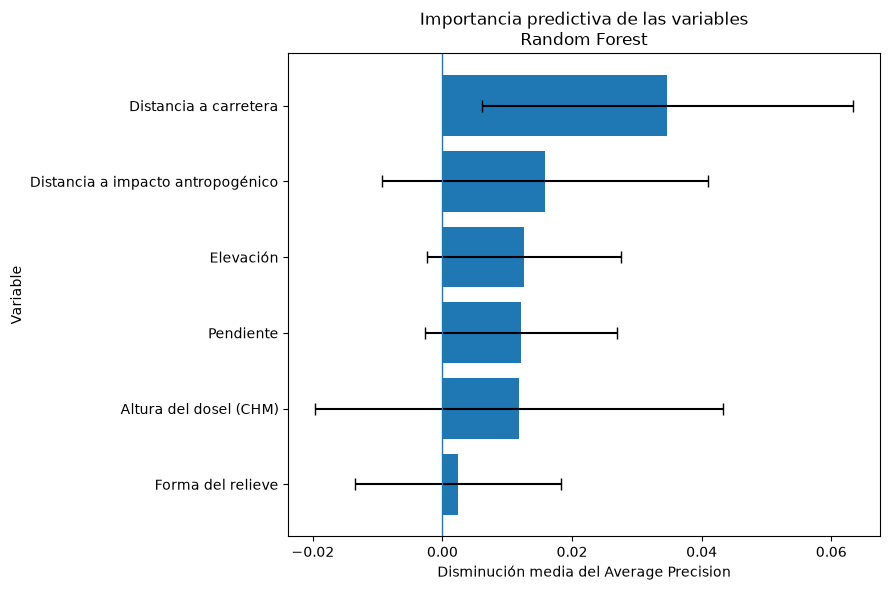

In [37]:
import matplotlib.pyplot as plt

# Preparar la tabla para graficar
fig_importancia = (
    importancia_grupal
    .reset_index()
    .sort_values("mean", ascending=True)
)

# Nombres más presentables
nombres_variables = {
    "dist_carretera_m": "Distancia a carretera",
    "dist_impact_m": "Distancia a impacto antropogénico",
    "elev_mean": "Elevación",
    "pend_mean": "Pendiente",
    "chm_mean": "Altura del dosel (CHM)",
    "forma_relieve": "Forma del relieve"
}

fig_importancia["variable_nombre"] = (
    fig_importancia["variable"]
    .map(nombres_variables)
)

# Crear figura
plt.figure(figsize=(9, 6))

plt.barh(
    fig_importancia["variable_nombre"],
    fig_importancia["mean"],
    xerr=fig_importancia["std"],
    capsize=4
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel(
    "Disminución media del Average Precision"
)

plt.ylabel("Variable")

plt.title(
    "Importancia predictiva de las variables\n"
    "Random Forest"
)

plt.tight_layout()

# Guardar
ruta_figuras = PROYECTO / "figuras"
ruta_figuras.mkdir(exist_ok=True)

plt.savefig(
    ruta_figuras / "objetivo4_importancia_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

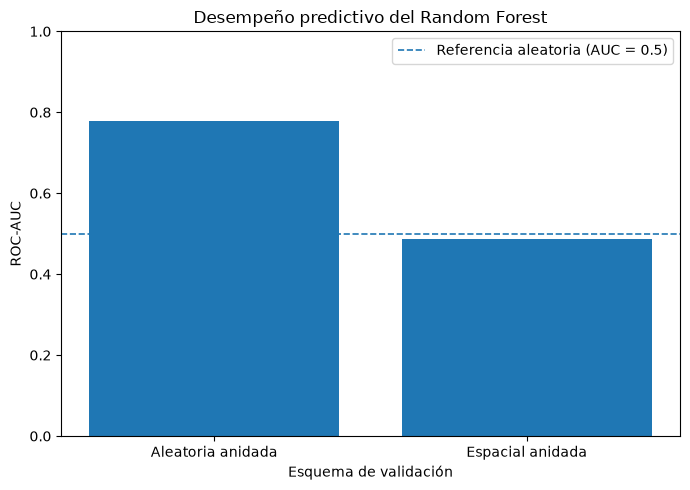

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

comparacion_auc = pd.DataFrame({
    "Validación": [
        "Aleatoria anidada",
        "Espacial anidada"
    ],
    "ROC_AUC": [
        0.7786667381708122,
        0.4865209099349424
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    comparacion_auc["Validación"],
    comparacion_auc["ROC_AUC"]
)

# Línea de referencia: desempeño equivalente al azar
plt.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1.2,
    label="Referencia aleatoria (AUC = 0.5)"
)

plt.ylim(0, 1)

plt.ylabel("ROC-AUC")

plt.xlabel("Esquema de validación")

plt.title(
    "Desempeño predictivo del Random Forest"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_auc_validacion_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

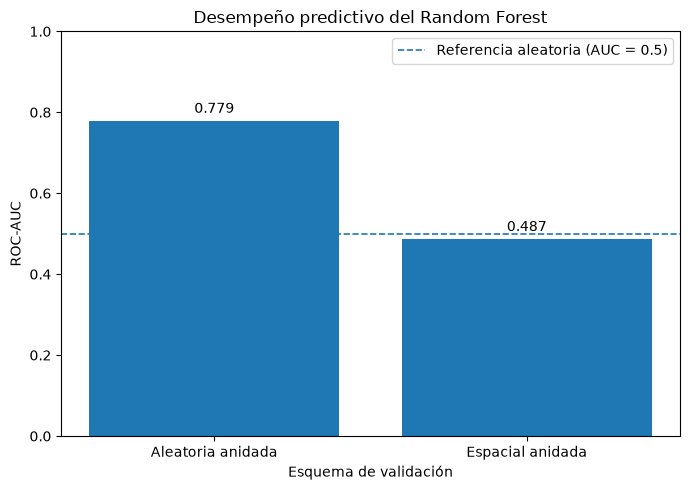

In [39]:
plt.figure(figsize=(7, 5))

barras = plt.bar(
    comparacion_auc["Validación"],
    comparacion_auc["ROC_AUC"]
)

plt.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1.2,
    label="Referencia aleatoria (AUC = 0.5)"
)

plt.ylim(0, 1)

plt.ylabel("ROC-AUC")
plt.xlabel("Esquema de validación")
plt.title("Desempeño predictivo del Random Forest")

# Agregar valores encima de las barras
for barra, valor in zip(
    barras,
    comparacion_auc["ROC_AUC"]
):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor + 0.02,
        f"{valor:.3f}",
        ha="center"
    )

plt.legend()
plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_auc_validacion_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

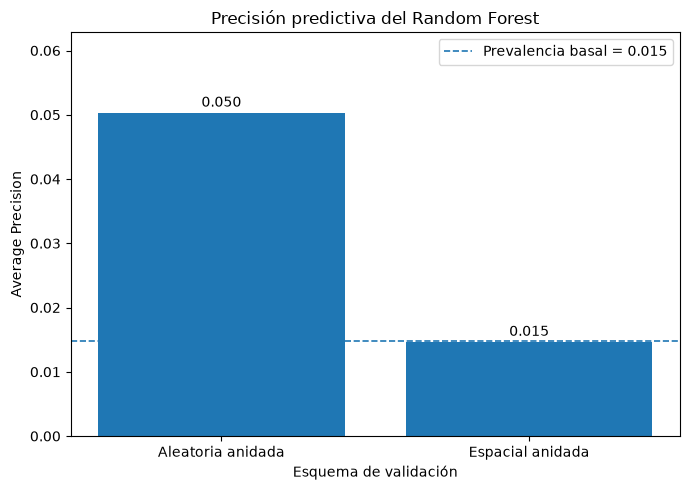

In [40]:
comparacion_ap = pd.DataFrame({
    "Validación": [
        "Aleatoria anidada",
        "Espacial anidada"
    ],
    "Average_Precision": [
        0.05026476712157774,
        0.01459905449378322
    ]
})

prevalencia = 0.014823008849557522

plt.figure(figsize=(7, 5))

barras = plt.bar(
    comparacion_ap["Validación"],
    comparacion_ap["Average_Precision"]
)

# Línea de referencia: prevalencia basal
plt.axhline(
    y=prevalencia,
    linestyle="--",
    linewidth=1.2,
    label=f"Prevalencia basal = {prevalencia:.3f}"
)

plt.ylabel("Average Precision")
plt.xlabel("Esquema de validación")

plt.title(
    "Precisión predictiva del Random Forest"
)

# Valores sobre las barras
for barra, valor in zip(
    barras,
    comparacion_ap["Average_Precision"]
):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor + 0.001,
        f"{valor:.3f}",
        ha="center"
    )

plt.ylim(
    0,
    comparacion_ap["Average_Precision"].max() * 1.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_average_precision_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

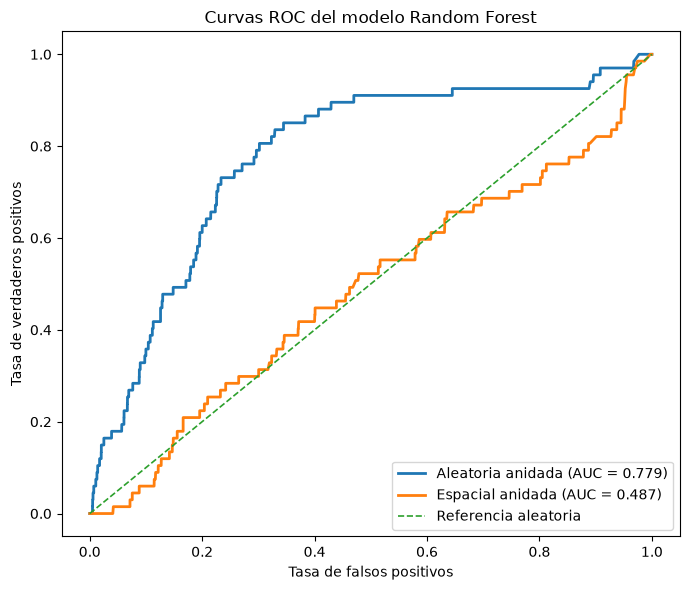

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Curva ROC - validación aleatoria
fpr_random, tpr_random, _ = roc_curve(
    y,
    prob_nested
)

auc_random = roc_auc_score(
    y,
    prob_nested
)

# Curva ROC - validación espacial
fpr_espacial, tpr_espacial, _ = roc_curve(
    y_espacial,
    prob_espacial_nested
)

auc_espacial = roc_auc_score(
    y_espacial,
    prob_espacial_nested
)

# Gráfico
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_random,
    tpr_random,
    linewidth=2,
    label=f"Aleatoria anidada (AUC = {auc_random:.3f})"
)

plt.plot(
    fpr_espacial,
    tpr_espacial,
    linewidth=2,
    label=f"Espacial anidada (AUC = {auc_espacial:.3f})"
)

# Línea de azar
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Referencia aleatoria"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.title(
    "Curvas ROC del modelo Random Forest"
)

plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_curvas_roc_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

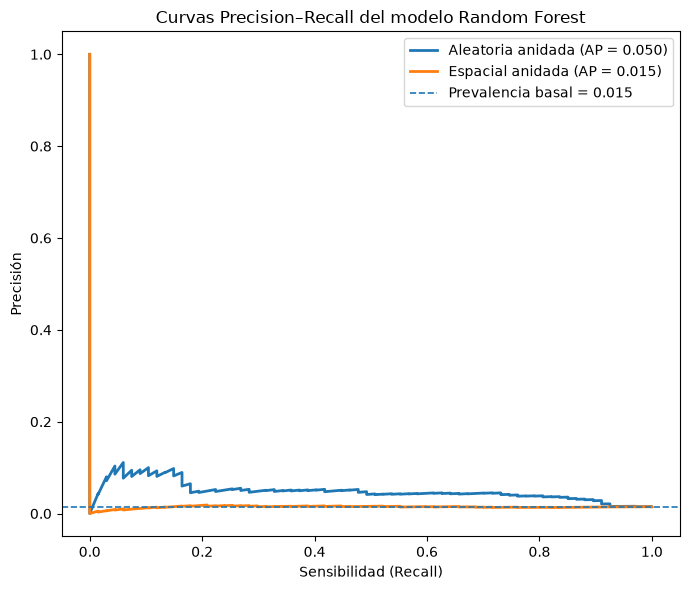

In [42]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Curva PR - validación aleatoria
precision_random, recall_random, _ = precision_recall_curve(
    y,
    prob_nested
)

ap_random = average_precision_score(
    y,
    prob_nested
)

# Curva PR - validación espacial
precision_espacial, recall_espacial, _ = precision_recall_curve(
    y_espacial,
    prob_espacial_nested
)

ap_espacial = average_precision_score(
    y_espacial,
    prob_espacial_nested
)

prevalencia = y.mean()

plt.figure(figsize=(7, 6))

plt.plot(
    recall_random,
    precision_random,
    linewidth=2,
    label=f"Aleatoria anidada (AP = {ap_random:.3f})"
)

plt.plot(
    recall_espacial,
    precision_espacial,
    linewidth=2,
    label=f"Espacial anidada (AP = {ap_espacial:.3f})"
)

# Referencia basal
plt.axhline(
    y=prevalencia,
    linestyle="--",
    linewidth=1.2,
    label=f"Prevalencia basal = {prevalencia:.3f}"
)

plt.xlabel("Sensibilidad (Recall)")
plt.ylabel("Precisión")

plt.title(
    "Curvas Precision–Recall del modelo Random Forest"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_curvas_precision_recall_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ValueError: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical features to floating point dtypes ahead of time to avoid problems.

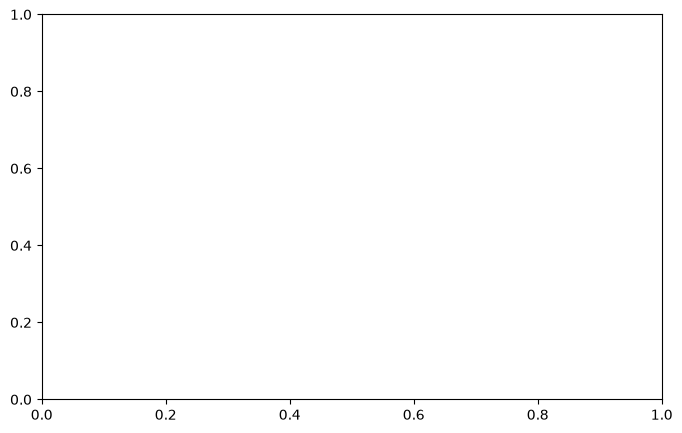

In [43]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    rf_final,
    X,
    features=["dist_carretera_m"],
    kind="average",
    grid_resolution=50,
    ax=ax
)

ax.set_xlabel("Distancia a carretera (m)")
ax.set_ylabel("Respuesta parcial del modelo")
ax.set_title(
    "Efecto parcial de la distancia a carretera\n"
    "Random Forest"
)

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_dependencia_distancia_carretera.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt

# Calcular dependencia parcial
pd_carretera = partial_dependence(
    rf_final,
    X,
    features=["dist_carretera_m"],
    kind="average",
    method="brute",
    response_method="predict_proba",
    grid_resolution=50
)

# Extraer valores
x_carretera = pd_carretera["grid_values"][0]
respuesta_carretera = pd_carretera["average"][0]

# Graficar
plt.figure(figsize=(8, 5))

plt.plot(
    x_carretera,
    respuesta_carretera,
    linewidth=2
)

plt.xlabel("Distancia a carretera (m)")
plt.ylabel("Respuesta parcial del modelo")

plt.title(
    "Dependencia parcial de la distancia a carretera\n"
    "Random Forest"
)

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_dependencia_distancia_carretera.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ValueError: The column 'dist_carretera_m' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical features to floating point dtypes ahead of time to avoid problems.

In [45]:
X_pd = X.copy()

variables_continuas = [
    "dist_carretera_m",
    "dist_impact_m",
    "elev_mean",
    "pend_mean",
    "chm_mean"
]

X_pd[variables_continuas] = (
    X_pd[variables_continuas]
    .astype(float)
)

print(X_pd.dtypes)

dist_carretera_m          float64
dist_impact_m             float64
elev_mean                 float64
pend_mean                 float64
chm_mean                  float64
forma_relieve_negativo      int64
forma_relieve_neutral       int64
forma_relieve_positivo      int64
dtype: object


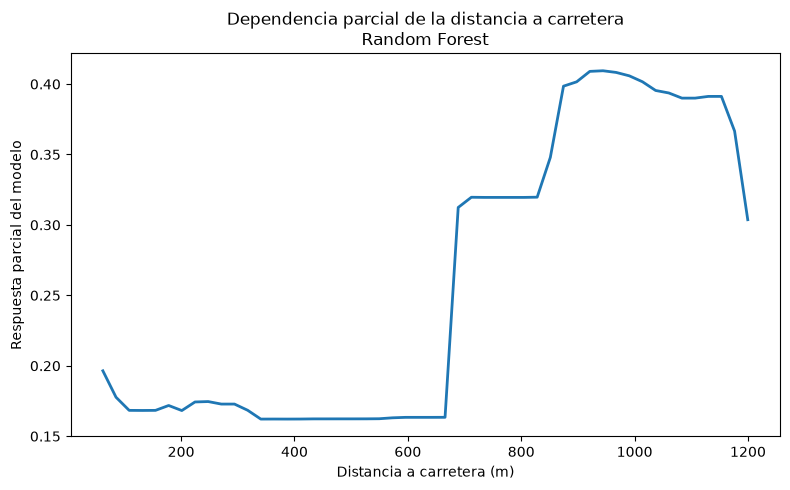

In [46]:
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt

pd_carretera = partial_dependence(
    rf_final,
    X_pd,
    features=["dist_carretera_m"],
    kind="average",
    method="brute",
    response_method="predict_proba",
    grid_resolution=50
)

x_carretera = pd_carretera["grid_values"][0]
respuesta_carretera = pd_carretera["average"][0]

plt.figure(figsize=(8, 5))

plt.plot(
    x_carretera,
    respuesta_carretera,
    linewidth=2
)

plt.xlabel("Distancia a carretera (m)")
plt.ylabel("Respuesta parcial del modelo")

plt.title(
    "Dependencia parcial de la distancia a carretera\n"
    "Random Forest"
)

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_dependencia_distancia_carretera.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

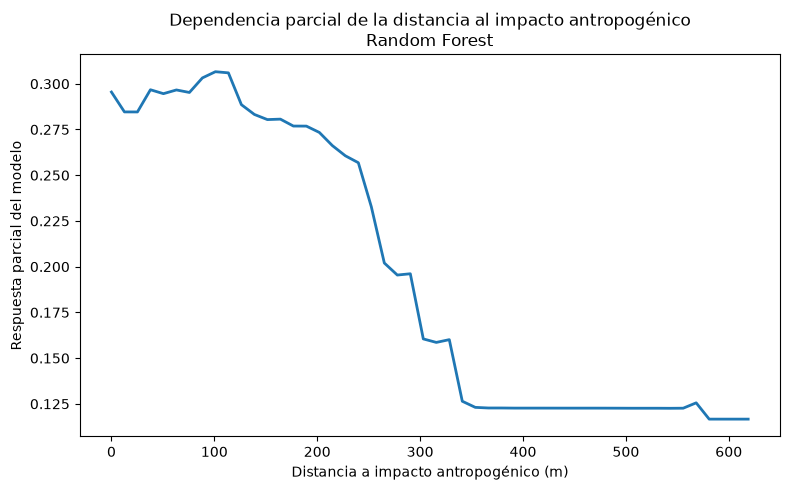

In [47]:
pd_impacto = partial_dependence(
    rf_final,
    X_pd,
    features=["dist_impact_m"],
    kind="average",
    method="brute",
    response_method="predict_proba",
    grid_resolution=50
)

x_impacto = pd_impacto["grid_values"][0]
respuesta_impacto = pd_impacto["average"][0]

plt.figure(figsize=(8, 5))

plt.plot(
    x_impacto,
    respuesta_impacto,
    linewidth=2
)

plt.xlabel("Distancia a impacto antropogénico (m)")
plt.ylabel("Respuesta parcial del modelo")

plt.title(
    "Dependencia parcial de la distancia al impacto antropogénico\n"
    "Random Forest"
)

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_dependencia_distancia_impacto.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

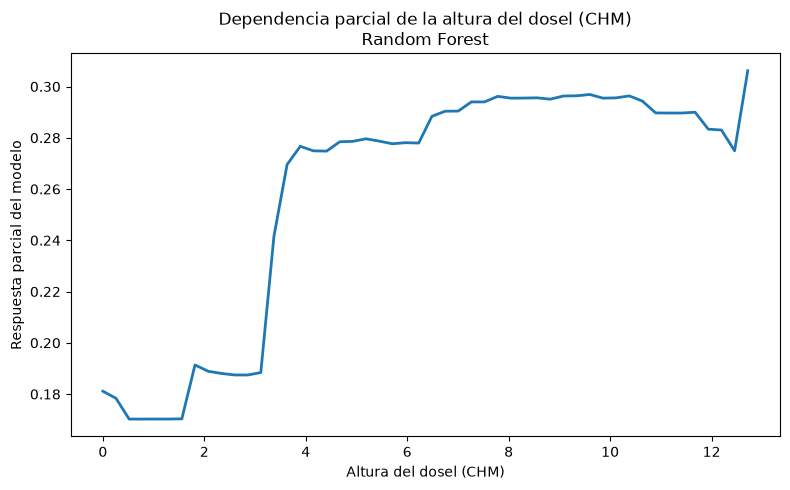

In [48]:
pd_chm = partial_dependence(
    rf_final,
    X_pd,
    features=["chm_mean"],
    kind="average",
    method="brute",
    response_method="predict_proba",
    grid_resolution=50
)

x_chm = pd_chm["grid_values"][0]
respuesta_chm = pd_chm["average"][0]

plt.figure(figsize=(8, 5))

plt.plot(
    x_chm,
    respuesta_chm,
    linewidth=2
)

plt.xlabel("Altura del dosel (CHM)")
plt.ylabel("Respuesta parcial del modelo")

plt.title(
    "Dependencia parcial de la altura del dosel (CHM)\n"
    "Random Forest"
)

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_dependencia_chm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

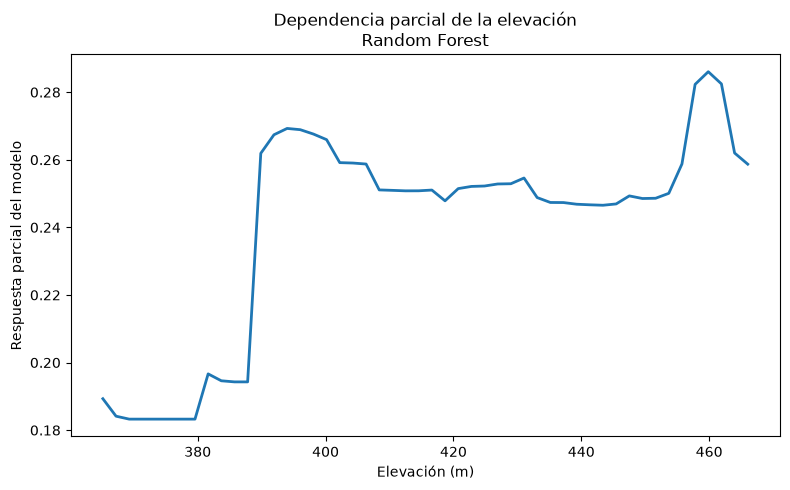

In [49]:
pd_elev = partial_dependence(
    rf_final,
    X_pd,
    features=["elev_mean"],
    kind="average",
    method="brute",
    response_method="predict_proba",
    grid_resolution=50
)

x_elev = pd_elev["grid_values"][0]
respuesta_elev = pd_elev["average"][0]

plt.figure(figsize=(8, 5))

plt.plot(
    x_elev,
    respuesta_elev,
    linewidth=2
)

plt.xlabel("Elevación (m)")
plt.ylabel("Respuesta parcial del modelo")

plt.title(
    "Dependencia parcial de la elevación\n"
    "Random Forest"
)

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_dependencia_elevacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

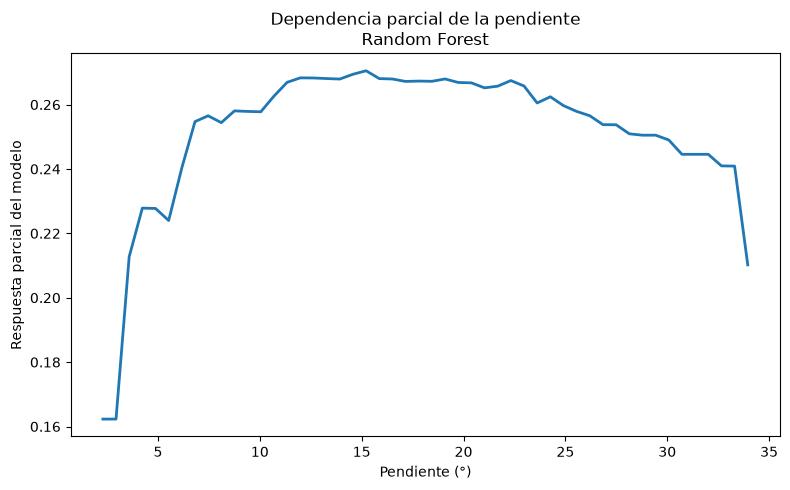

In [50]:
pd_pend = partial_dependence(
    rf_final,
    X_pd,
    features=["pend_mean"],
    kind="average",
    method="brute",
    response_method="predict_proba",
    grid_resolution=50
)

x_pend = pd_pend["grid_values"][0]
respuesta_pend = pd_pend["average"][0]

plt.figure(figsize=(8, 5))

plt.plot(
    x_pend,
    respuesta_pend,
    linewidth=2
)

plt.xlabel("Pendiente (°)")
plt.ylabel("Respuesta parcial del modelo")

plt.title(
    "Dependencia parcial de la pendiente\n"
    "Random Forest"
)

plt.tight_layout()

plt.savefig(
    ruta_figuras / "objetivo4_dependencia_pendiente.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
pd_resultados = pd.concat([
    pd.DataFrame({
        "variable": "Distancia a carretera",
        "valor": x_carretera,
        "respuesta_parcial": respuesta_carretera
    }),

    pd.DataFrame({
        "variable": "Distancia a impacto antropogénico",
        "valor": x_impacto,
        "respuesta_parcial": respuesta_impacto
    }),

    pd.DataFrame({
        "variable": "CHM",
        "valor": x_chm,
        "respuesta_parcial": respuesta_chm
    }),

    pd.DataFrame({
        "variable": "Elevación",
        "valor": x_elev,
        "respuesta_parcial": respuesta_elev
    }),

    pd.DataFrame({
        "variable": "Pendiente",
        "valor": x_pend,
        "respuesta_parcial": respuesta_pend
    })
], ignore_index=True)

pd_resultados.to_csv(
    ruta_resultados_python / "dependencias_parciales_rf.csv",
    index=False
)

print(pd_resultados.groupby("variable").size())

print(
    "\nGuardado en:",
    ruta_resultados_python / "dependencias_parciales_rf.csv"
)

variable
CHM                                  50
Distancia a carretera                50
Distancia a impacto antropogénico    50
Elevación                            50
Pendiente                            50
dtype: int64

Guardado en: C:\Users\HP\Documents\Tesis\R\tesis_solenodon\resultados\python\dependencias_parciales_rf.csv


In [52]:
# Predicciones de validación aleatoria
pred_aleatoria = datos[
    ["id_segmento", "deteccion_forrajeo"]
].copy()

pred_aleatoria["prob_rf_nested_aleatoria"] = prob_nested


# Predicciones de validación espacial
pred_espacial = datos_geo[
    [
        "id_segmento",
        "deteccion_forrajeo",
        "bloque_espacial_4"
    ]
].copy()

pred_espacial["prob_rf_nested_espacial"] = (
    prob_espacial_nested
)


# Unir por id de segmento
predicciones_finales = pred_aleatoria.merge(
    pred_espacial[
        [
            "id_segmento",
            "bloque_espacial_4",
            "prob_rf_nested_espacial"
        ]
    ],
    on="id_segmento",
    how="left"
)


# Guardar
predicciones_finales.to_csv(
    ruta_resultados_python /
    "predicciones_validacion_random_forest.csv",
    index=False
)

print(predicciones_finales.shape)
print(predicciones_finales.head())

print(
    "\nGuardado en:",
    ruta_resultados_python /
    "predicciones_validacion_random_forest.csv"
)

(4520, 5)
   id_segmento  deteccion_forrajeo  prob_rf_nested_aleatoria  \
0            2                   0                  0.087161   
1            3                   0                  0.106819   
2            4                   0                  0.128441   
3            5                   0                  0.325822   
4            6                   0                  0.041443   

   bloque_espacial_4  prob_rf_nested_espacial  
0                  2                 0.362373  
1                  2                 0.328292  
2                  2                 0.333754  
3                  2                 0.316251  
4                  2                 0.337370  

Guardado en: C:\Users\HP\Documents\Tesis\R\tesis_solenodon\resultados\python\predicciones_validacion_random_forest.csv


In [53]:
variables_obj2 = [
    "dist_carretera_m",
    "dist_impact_m",
    "elev_mean",
    "pend_mean",
    "chm_mean"
]

resumen_obj2 = (
    datos
    .groupby("deteccion_forrajeo")[variables_obj2]
    .agg([
        "count",
        "mean",
        "std",
        "median",
        "min",
        "max"
    ])
)

resumen_obj2

dist_carretera_m                                           \
                              count        mean         std median min   max   
deteccion_forrajeo                                                             
0                              4453  481.700427  382.543788  325.0   0  1416   
1                                67  780.716418  339.653424  918.0  60  1191   

                   dist_impact_m                                      ...  \
                           count        mean         std      median  ...   
deteccion_forrajeo                                                    ...   
0                           4453  211.398388  193.082671  145.241391  ...   
1                             67  127.587949   97.192654  115.753401  ...   

                    pend_mean                                 chm_mean  \
                          std     median       min        max    count   
deteccion_forrajeo                                                       
0                   10.008335  12.806212  0.254644  53.136542     4453   
1                    8.897672  14.801864  3.475204  49.011328       67   

                                                                  
                        mean       std    median  min        max  
deteccion_forrajeo                                                
0                   4.816942  4.386314  4.048193  0.0  23.059406  
1                   6.764963  3.941940  7.117647  0.0  15.303030  

[2 rows x 30 columns]

In [54]:
resumen_obj2_largo = (
    datos
    .groupby("deteccion_forrajeo")[variables_obj2]
    .agg(
        ["count", "mean", "std", "median", "min", "max"]
    )
    .round(2)
)

resumen_obj2_largo

dist_carretera_m                                   \
                              count    mean     std median min   max   
deteccion_forrajeo                                                     
0                              4453  481.70  382.54  325.0   0  1416   
1                                67  780.72  339.65  918.0  60  1191   

                   dist_impact_m                          ... pend_mean  \
                           count    mean     std  median  ...       std   
deteccion_forrajeo                                        ...             
0                           4453  211.40  193.08  145.24  ...     10.01   
1                             67  127.59   97.19  115.75  ...      8.90   

                                       chm_mean                                 
                   median   min    max    count  mean   std median  min    max  
deteccion_forrajeo                                                              
0                   12.81  0.25  53.14     4453  4.82  4.39   4.05  0.0  23.06  
1                   14.80  3.48  49.01       67  6.76  3.94   7.12  0.0  15.30  

[2 rows x 30 columns]

In [55]:
tabla_obj2 = (
    datos
    .groupby("deteccion_forrajeo")[variables_obj2]
    .agg(["mean", "median", "std"])
    .round(2)
    .T
)

tabla_obj2.columns = [
    "Sin detección",
    "Con detección"
]

tabla_obj2

Sin detección  Con detección
dist_carretera_m mean           481.70         780.72
                 median         325.00         918.00
                 std            382.54         339.65
dist_impact_m    mean           211.40         127.59
                 median         145.24         115.75
                 std            193.08          97.19
elev_mean        mean           421.77         425.79
                 median         429.21         429.70
                 std             30.47          26.08
pend_mean        mean            14.60          16.16
                 median          12.81          14.80
                 std             10.01           8.90
chm_mean         mean             4.82           6.76
                 median           4.05           7.12
                 std              4.39           3.94

In [56]:
tabla_relieve = pd.crosstab(
    datos["forma_relieve"],
    datos["deteccion_forrajeo"]
)

tabla_relieve.columns = [
    "Sin detección",
    "Con detección"
]

tabla_relieve

,Sin detección,Con detección
forma_relieve,,
negativo,2081,37
neutral,1179,18
positivo,1193,12


In [57]:
porcentaje_relieve = pd.crosstab(
    datos["forma_relieve"],
    datos["deteccion_forrajeo"],
    normalize="columns"
) * 100

porcentaje_relieve.columns = [
    "Sin detección (%)",
    "Con detección (%)"
]

porcentaje_relieve = porcentaje_relieve.round(2)

porcentaje_relieve

,Sin detección (%),Con detección (%)
forma_relieve,,
negativo,46.73,55.22
neutral,26.48,26.87
positivo,26.79,17.91


In [58]:
tasa_relieve = pd.DataFrame({
    "Sin detección": tabla_relieve["Sin detección"],
    "Con detección": tabla_relieve["Con detección"]
})

tasa_relieve["Total"] = (
    tasa_relieve["Sin detección"] +
    tasa_relieve["Con detección"]
)

tasa_relieve["Tasa detección (%)"] = (
    tasa_relieve["Con detección"] /
    tasa_relieve["Total"] * 100
).round(2)

tasa_relieve

,Sin detección,Con detección,Total,Tasa detección (%)
forma_relieve,,,,
negativo,2081,37,2118,1.75
neutral,1179,18,1197,1.50
positivo,1193,12,1205,1.00


In [59]:
ruta_obj2 = PROYECTO / "resultados" / "python"

# Variables continuas
tabla_obj2.to_csv(
    ruta_obj2 / "objetivo2_resumen_variables_continuas.csv"
)

# Frecuencias de relieve
tabla_relieve.to_csv(
    ruta_obj2 / "objetivo2_frecuencias_relieve.csv"
)

# Porcentajes de relieve
porcentaje_relieve.to_csv(
    ruta_obj2 / "objetivo2_porcentajes_relieve.csv"
)

# Tasas de detección por relieve
tasa_relieve.to_csv(
    ruta_obj2 / "objetivo2_tasa_deteccion_relieve.csv"
)

print("Archivos del Objetivo 2 guardados correctamente.")

Archivos del Objetivo 2 guardados correctamente.


In [60]:
tabla_final_obj2 = pd.DataFrame({
    "Variable": [
        "Distancia a carretera (m)",
        "Distancia a impacto antropogénico (m)",
        "Elevación (m)",
        "Pendiente (°)",
        "Altura del dosel - CHM (m)"
    ],

    "Media sin detección": [
        481.70,
        211.40,
        421.77,
        14.60,
        4.82
    ],

    "Media con detección": [
        780.72,
        127.59,
        425.79,
        16.16,
        6.76
    ],

    "Mediana sin detección": [
        325.00,
        145.24,
        429.21,
        12.81,
        4.05
    ],

    "Mediana con detección": [
        918.00,
        115.75,
        429.70,
        14.80,
        7.12
    ],

    "DE sin detección": [
        382.54,
        193.08,
        30.47,
        10.01,
        4.39
    ],

    "DE con detección": [
        339.65,
        97.19,
        26.08,
        8.90,
        3.94
    ]
})

tabla_final_obj2

,Variable,Media sin detección,Media con detección,Mediana sin detección,Mediana con detección,DE sin detección,DE con detección
0,Distancia a carretera (m),481.70,780.72,325.00,918.00,382.54,339.65
1,Distancia a impacto antropogénico (m),211.40,127.59,145.24,115.75,193.08,97.19
2,Elevación (m),421.77,425.79,429.21,429.70,30.47,26.08
3,Pendiente (°),14.60,16.16,12.81,14.80,10.01,8.90
4,Altura del dosel - CHM (m),4.82,6.76,4.05,7.12,4.39,3.94


In [61]:
tabla_final_obj2.to_csv(
    ruta_obj2 / "objetivo2_tabla_final_descriptiva.csv",
    index=False
)

print("Tabla final del Objetivo 2 guardada.")

Tabla final del Objetivo 2 guardada.


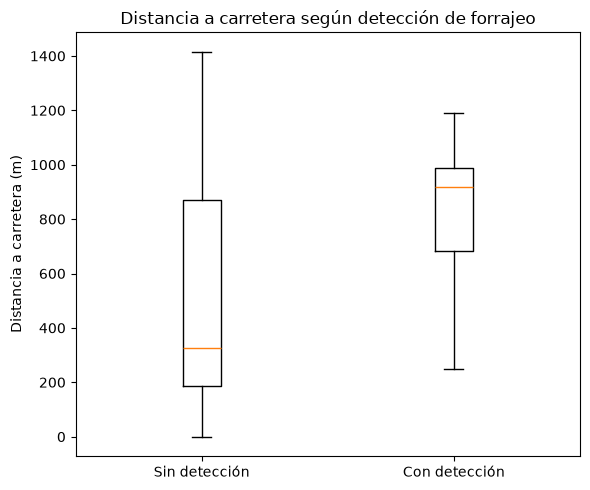

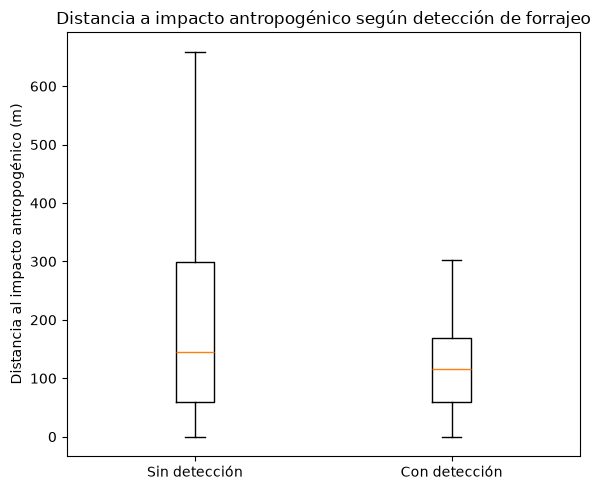

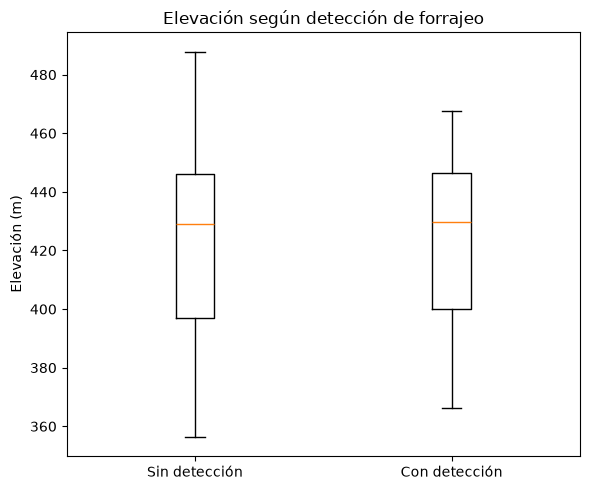

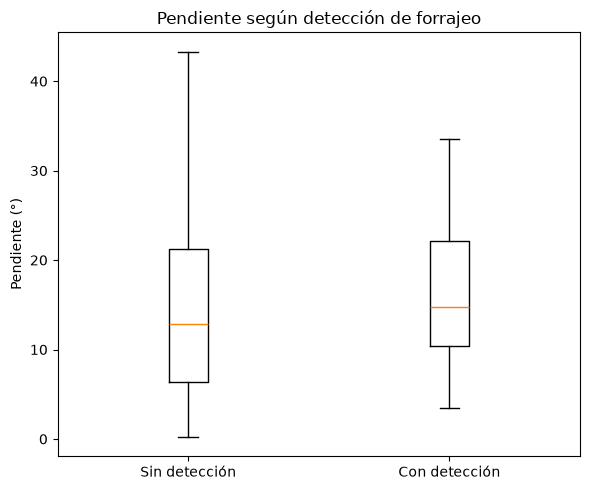

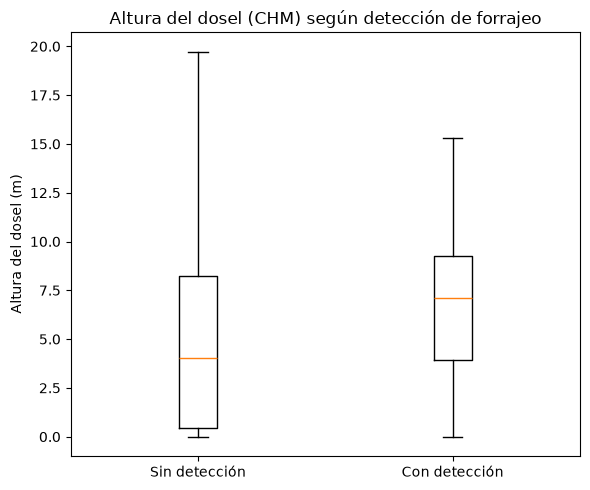

In [62]:
import matplotlib.pyplot as plt

variables_graficas = {
    "dist_carretera_m": (
        "Distancia a carretera",
        "Distancia a carretera (m)",
        "objetivo2_distancia_carretera.png"
    ),

    "dist_impact_m": (
        "Distancia a impacto antropogénico",
        "Distancia al impacto antropogénico (m)",
        "objetivo2_distancia_impacto.png"
    ),

    "elev_mean": (
        "Elevación",
        "Elevación (m)",
        "objetivo2_elevacion.png"
    ),

    "pend_mean": (
        "Pendiente",
        "Pendiente (°)",
        "objetivo2_pendiente.png"
    ),

    "chm_mean": (
        "Altura del dosel (CHM)",
        "Altura del dosel (m)",
        "objetivo2_chm.png"
    )
}

for variable, (titulo, ylabel, archivo) in variables_graficas.items():

    sin_det = datos.loc[
        datos["deteccion_forrajeo"] == 0,
        variable
    ]

    con_det = datos.loc[
        datos["deteccion_forrajeo"] == 1,
        variable
    ]

    plt.figure(figsize=(6, 5))

    plt.boxplot(
        [sin_det, con_det],
        tick_labels=[
            "Sin detección",
            "Con detección"
        ],
        showfliers=False
    )

    plt.ylabel(ylabel)

    plt.title(
        f"{titulo} según detección de forrajeo"
    )

    plt.tight_layout()

    plt.savefig(
        ruta_figuras / archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()